# Fast Real vs Fake Face Detection Training

This notebook is an optimized Colab/local-training version of `fake-face-detection-with-keras-accuracy-0-987.ipynb`.

It is tuned for either:

- Google Colab T4 with persistent Google Drive storage.
- A local 16 GB RAM, RTX 1650 Ti, Intel i7 10th gen machine.

The original notebook is accurate but expensive locally because it trains DenseNet121 at 256x256 over the full 140k-image dataset. This version is tuned for a 30-40 minute first training run:

- MobileNetV2 backbone instead of DenseNet121/Xception for much faster training.
- 192x192 images by default to reduce GPU memory and step time.
- Balanced class sampling so early runs do not need all 140k images.
- Frozen-backbone warmup, then short fine-tuning of only the last layers.
- `tf.data` pipeline with parallel decode, shuffle, and prefetch.
- Colab Drive persistence for dataset, checkpoints, final model, and threshold.
- Resume logic so a disconnected Colab runtime can continue from the latest saved checkpoint after Drive is remounted.

For best accuracy after the quick run works, increase `TRAIN_SAMPLES_PER_CLASS`, set `IMG_SIZE = 224`, and fine-tune for a few more epochs.


In [1]:
import json
import os
import random
import shutil
import subprocess
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn import metrics

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

IN_COLAB = "google.colab" in sys.modules

print("TensorFlow:", tf.__version__)
print("Running in Colab:", IN_COLAB)
print("GPUs:", tf.config.list_physical_devices("GPU"))

# Memory growth avoids TensorFlow grabbing all GPU VRAM upfront.
for gpu in tf.config.list_physical_devices("GPU"):
    tf.config.experimental.set_memory_growth(gpu, True)


TensorFlow: 2.20.0
Running in Colab: True
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## Configuration

When running in Colab, this notebook mounts Google Drive and stores everything under:

`/content/drive/MyDrive/DeepShield/fake-face-training`

That folder contains:

- `data/real-vs-fake` for the downloaded Kaggle dataset.
- `trained_models` for checkpoints, final Keras models, and threshold JSON.
- `training_state.json` for lightweight resume metadata.

If Colab disconnects, rerun the notebook from the top. It will remount Drive, reuse the dataset, load the latest checkpoint if present, and continue training.

The first Kaggle download is large. If Kaggle asks for authentication, upload your Kaggle API token to Colab at `/root/.kaggle/kaggle.json`, or put it in Drive and copy it before running the download cell.


In [19]:
KAGGLE_DATASET = "xhlulu/140k-real-and-fake-faces"
AUTO_DOWNLOAD_DATA = True
FORCE_REMOUNT_DRIVE = False

DRIVE_PROJECT_DIR = Path("/content/drive/MyDrive/DeepShield/fake-face-training")
LOCAL_PROJECT_DIR = Path(".")

PROJECT_DIR = DRIVE_PROJECT_DIR if IN_COLAB else LOCAL_PROJECT_DIR

if IN_COLAB:
    from google.colab import drive
    drive.mount("/content/drive", force_remount=FORCE_REMOUNT_DRIVE)
    PROJECT_DIR.mkdir(parents=True, exist_ok=True)

MAIN_PATH = Path(os.environ.get("REAL_VS_FAKE_PATH", str(PROJECT_DIR / "data" / "real-vs-fake")))

# --- UPGRADED SETTINGS FOR 90%+ ACCURACY ---
IMG_SIZE = 224
BATCH_SIZE = 32

# Increase data volume for better generalization
TRAIN_SAMPLES_PER_CLASS = 25_000
VALID_SAMPLES_PER_CLASS = 5_000
TEST_SAMPLES_PER_CLASS = 2_500

WARMUP_EPOCHS = 5
FINETUNE_EPOCHS = 5
FINE_TUNE_LAST_N_LAYERS = 50
# -------------------------------------------

MODEL_DIR = PROJECT_DIR / "trained_models"
MODEL_DIR.mkdir(parents=True, exist_ok=True)
MODEL_PATH = MODEL_DIR / "deepfake_densenet121_high_acc.keras"
CHECKPOINT_PATH = MODEL_DIR / "deepfake_densenet121_latest.keras"
THRESHOLD_PATH = MODEL_DIR / "deepfake_densenet121_threshold.json"
TRAINING_STATE_PATH = MODEL_DIR / "training_state.json"

print("Project dir:", PROJECT_DIR.resolve())
print("Upgraded for high accuracy: DenseNet121 @ 224x224")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Project dir: /content/drive/MyDrive/DeepShield/fake-face-training
Upgraded for high accuracy: DenseNet121 @ 224x224


## Automatic dataset download

Run this cell before collecting image paths. It is safe to rerun: if `data/real-vs-fake/train`, `valid`, and `test` already exist, it skips the download.


In [32]:
def split_folders_exist(root: Path) -> bool:
    return all((root / split / class_name).exists() for split in ["train", "valid", "test"] for class_name in ["fake", "real"])


def find_real_vs_fake_root(download_root: Path) -> Path:
    common_candidates = [
        download_root,
        download_root / "real_vs_fake" / "real-vs-fake",
        download_root / "real-vs-fake",
    ]
    for candidate in common_candidates:
        if split_folders_exist(candidate):
            return candidate

    for train_dir in download_root.rglob("train"):
        candidate = train_dir.parent
        if split_folders_exist(candidate):
            return candidate

    raise FileNotFoundError(
        f"Could not find train/valid/test folders with fake/real classes under {download_root}"
    )


def ensure_package(package_name: str, import_name: str | None = None):
    import_name = import_name or package_name
    try:
        return __import__(import_name)
    except ImportError:
        print(f"Installing {package_name}...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", package_name])
        return __import__(import_name)


def prepare_kaggle_credentials():
    kaggle_dir = Path.home() / ".kaggle"
    kaggle_json = kaggle_dir / "kaggle.json"
    if kaggle_json.exists():
        return

    drive_candidates = [
        PROJECT_DIR / "kaggle.json",
        PROJECT_DIR.parent / "kaggle.json",
        Path("/content/drive/MyDrive/kaggle.json"),
    ]
    for candidate in drive_candidates:
        if candidate.exists():
            kaggle_dir.mkdir(parents=True, exist_ok=True)
            shutil.copy2(candidate, kaggle_json)
            try:
                kaggle_json.chmod(0o600)
            except OSError:
                pass
            print("Copied Kaggle credentials from Drive to", kaggle_json)
            return


def ensure_dataset():
    # We check if counts match the globals to decide if we need to rerun selective copy
    # This is more robust than split_folders_exist when targets increase.
    prepare_kaggle_credentials()
    kagglehub = ensure_package("kagglehub")
    from tqdm.auto import tqdm

    print("Checking/Downloading Kaggle dataset:", KAGGLE_DATASET)
    downloaded_path = Path(kagglehub.dataset_download(KAGGLE_DATASET))
    source_root = find_real_vs_fake_root(downloaded_path)

    print("Selective copy check to:", MAIN_PATH.resolve())
    current_limits = {
        "train": TRAIN_SAMPLES_PER_CLASS,
        "valid": VALID_SAMPLES_PER_CLASS,
        "test": TEST_SAMPLES_PER_CLASS
    }

    for split, limit in current_limits.items():
        for cls in ["fake", "real"]:
            src = source_root / split / cls
            dst = MAIN_PATH / split / cls
            dst.mkdir(parents=True, exist_ok=True)

            # Get existing files to skip
            existing = {f.name for f in dst.glob("*") if f.stat().st_size > 0}
            files_needed = sorted(list(src.glob("*")))[:limit]

            to_copy = [f for f in files_needed if f.name not in existing]

            if to_copy:
                print(f"Copying {len(to_copy)} new/missing files to {split}/{cls}...")
                for f in tqdm(to_copy, desc=f"{split}/{cls}"):
                    shutil.copy2(f, dst)

    print("\nDataset ready and verified:", MAIN_PATH.resolve())


ensure_dataset()

TRAIN_DIR = MAIN_PATH / "train"
VALID_DIR = MAIN_PATH / "valid"
TEST_DIR = MAIN_PATH / "test"

print("Dataset root:", MAIN_PATH.resolve())

Checking/Downloading Kaggle dataset: xhlulu/140k-real-and-fake-faces
Using Colab cache for faster access to the '140k-real-and-fake-faces' dataset.
Selective copy check to: /content/drive/MyDrive/DeepShield/fake-face-training/data/real-vs-fake
Copying 12733 new/missing files to train/fake...


train/fake:   0%|          | 0/12733 [00:00<?, ?it/s]

Copying 20000 new/missing files to train/real...


train/real:   0%|          | 0/20000 [00:00<?, ?it/s]

Copying 1 new/missing files to valid/fake...


valid/fake:   0%|          | 0/1 [00:00<?, ?it/s]


Dataset ready and verified: /content/drive/MyDrive/DeepShield/fake-face-training/data/real-vs-fake
Dataset root: /content/drive/MyDrive/DeepShield/fake-face-training/data/real-vs-fake


In [39]:
def verify_dataset_integrity(root_path: Path, expected_limits: dict):
    print(f"Verifying dataset at: {root_path.resolve()}")
    all_good = True
    for split, limit in expected_limits.items():
        for cls in ['fake', 'real']:
            path = root_path / split / cls
            if not path.exists():
                print(f"[MISSING FOLDER] {path}")
                all_good = False
                continue

            files = list(path.glob('*'))
            count = len(files)
            empty_files = [f for f in files if f.stat().st_size == 0]

            status = "OK" if count >= limit else "INCOMPLETE"
            print(f"{split}/{cls}: Found {count}/{limit} images. Empty files: {len(empty_files)} [{status}]")

            if count < limit or len(empty_files) > 0:
                all_good = False

    if all_good:
        print("\nOverall Status: PASS. Dataset is ready for training.")
    else:
        print("\nOverall Status: FAIL. Please rerun the dataset preparation cell (5a70ade8).")

limits = {
    'train': TRAIN_SAMPLES_PER_CLASS,
    'valid': VALID_SAMPLES_PER_CLASS,
    'test': TEST_SAMPLES_PER_CLASS
}
verify_dataset_integrity(MAIN_PATH, limits)

Verifying dataset at: /content/drive/MyDrive/DeepShield/fake-face-training/data/real-vs-fake
train/fake: Found 34076/25000 images. Empty files: 0 [OK]
train/real: Found 25000/25000 images. Empty files: 0 [OK]
valid/fake: Found 10000/5000 images. Empty files: 0 [OK]
valid/real: Found 10000/5000 images. Empty files: 0 [OK]
test/fake: Found 10000/2500 images. Empty files: 0 [OK]
test/real: Found 10000/2500 images. Empty files: 0 [OK]

Overall Status: PASS. Dataset is ready for training.


In [31]:
import os

def remove_empty_files(root_path: Path):
    print(f"Scanning for 0-byte files in: {root_path}")
    deleted_count = 0

    for root, dirs, files in os.walk(root_path):
        for file in files:
            file_path = Path(root) / file
            try:
                if file_path.stat().st_size == 0:
                    file_path.unlink()  # Deletes the file
                    deleted_count += 1
            except Exception as e:
                print(f"Error checking {file_path}: {e}")

    print(f"Done. Removed {deleted_count} empty files.")

# Run the cleanup
remove_empty_files(MAIN_PATH)

Scanning for 0-byte files in: /content/drive/MyDrive/DeepShield/fake-face-training/data/real-vs-fake
Done. Removed 2 empty files.


In [33]:
IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".webp"}
CLASS_NAMES = ["fake", "real"]
CLASS_TO_LABEL = {"fake": 0, "real": 1}


def collect_split(split_dir: Path, samples_per_class=None) -> pd.DataFrame:
    rows = []
    for class_name in CLASS_NAMES:
        class_dir = split_dir / class_name
        if not class_dir.exists():
            raise FileNotFoundError(f"Missing class folder: {class_dir}")
        files = [p for p in class_dir.rglob("*") if p.suffix.lower() in IMAGE_EXTENSIONS]
        random.Random(SEED).shuffle(files)
        if samples_per_class is not None:
            files = files[:samples_per_class]
        rows.extend({"path": str(p), "label": CLASS_TO_LABEL[class_name], "class_name": class_name} for p in files)
    df = pd.DataFrame(rows)
    if df.empty:
        raise ValueError(f"No images found under {split_dir}")
    return df.sample(frac=1.0, random_state=SEED).reset_index(drop=True)

train_df = collect_split(TRAIN_DIR, TRAIN_SAMPLES_PER_CLASS)
valid_df = collect_split(VALID_DIR, VALID_SAMPLES_PER_CLASS)
test_df = collect_split(TEST_DIR, TEST_SAMPLES_PER_CLASS)

for name, df in [("train", train_df), ("valid", valid_df), ("test", test_df)]:
    print(name, len(df))
    print(df["class_name"].value_counts().to_string())


train 50000
class_name
real    25000
fake    25000
valid 10000
class_name
real    5000
fake    5000
test 5000
class_name
fake    2500
real    2500


In [34]:
AUTOTUNE = tf.data.AUTOTUNE


def load_image(path, label):
    image_bytes = tf.io.read_file(path)
    image = tf.io.decode_image(image_bytes, channels=3, expand_animations=False)
    image = tf.image.resize(image, [IMG_SIZE, IMG_SIZE], method="bilinear")
    image = tf.cast(image, tf.float32)
    label = tf.cast(label, tf.float32)
    return image, label


def make_dataset(df: pd.DataFrame, training: bool) -> tf.data.Dataset:
    paths = df["path"].to_numpy()
    labels = df["label"].to_numpy(dtype=np.float32)
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    if training:
        ds = ds.shuffle(min(len(df), 10_000), seed=SEED, reshuffle_each_iteration=True)
    ds = ds.map(load_image, num_parallel_calls=AUTOTUNE)
    ds = ds.batch(BATCH_SIZE, drop_remainder=training)
    ds = ds.prefetch(AUTOTUNE)
    return ds

train_ds = make_dataset(train_df, training=True)
valid_ds = make_dataset(valid_df, training=False)
test_ds = make_dataset(test_df, training=False)


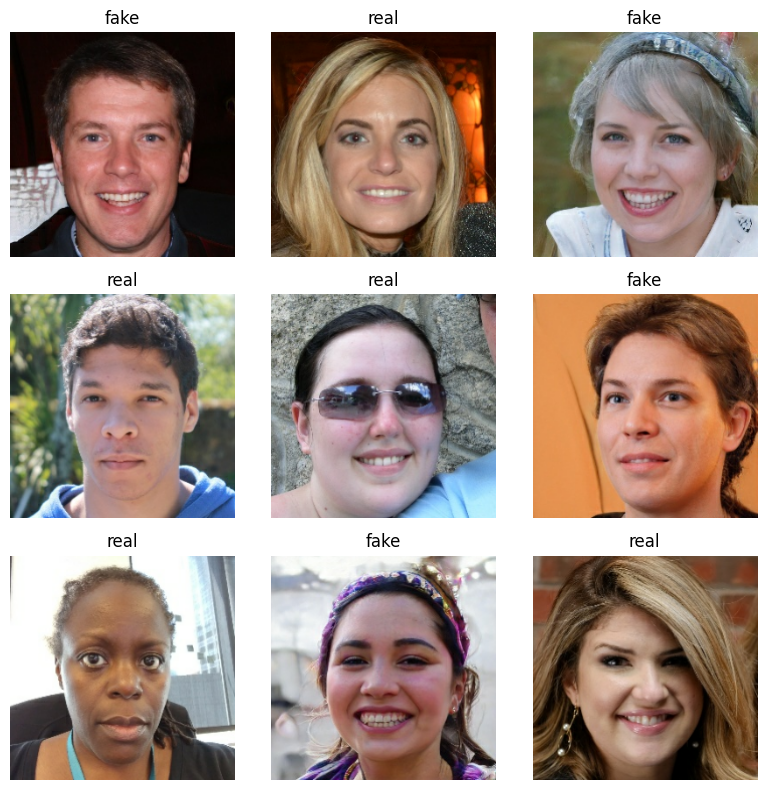

In [35]:
plt.figure(figsize=(8, 8))
for images, labels in train_ds.take(1):
    for i in range(min(9, images.shape[0])):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(CLASS_NAMES[int(labels[i].numpy())])
        plt.axis("off")
plt.tight_layout()


## Model

MobileNetV2 is the default because it is a good speed/accuracy tradeoff for a 4 GB class GPU. The output score is close to `1` for real and close to `0` for fake, matching the original notebook.


In [36]:
def build_model():
    inputs = tf.keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3), name="image")
    x = tf.keras.layers.RandomFlip("horizontal", seed=SEED)(inputs)
    x = tf.keras.layers.RandomRotation(0.05, seed=SEED)(x)
    x = tf.keras.layers.RandomZoom(0.1, seed=SEED)(x)

    # Switching to DenseNet121 for higher feature extraction capability
    x = tf.keras.applications.densenet.preprocess_input(x)

    base = tf.keras.applications.DenseNet121(
        include_top=False,
        weights="imagenet",
        input_shape=(IMG_SIZE, IMG_SIZE, 3),
    )
    base.trainable = False

    x = base(x, training=False)
    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    x = tf.keras.layers.Dropout(0.4)(x)
    x = tf.keras.layers.Dense(256, activation="relu")(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Dropout(0.3)(x)
    outputs = tf.keras.layers.Dense(1, activation="sigmoid", name="real_probability")(x)
    return tf.keras.Model(inputs, outputs, name="deepfake_densenet121")

model = build_model()
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss="binary_crossentropy",
    metrics=["accuracy", tf.keras.metrics.AUC(name="auc")]
)
model.summary()

Model: "deepfake_densenet121"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ image (InputLayer)              │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_flip_2 (RandomFlip)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation_2               │ (None, 224, 224, 3)    │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom_2 (RandomZoom)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide_3 (TrueDivide)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ add_1 (Add)                     │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide_4 (TrueDivide)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ densenet121 (Functional)        │ (None, 7, 7, 1024)     │     7,037,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 1024)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       262,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ real_probability (Dense)        │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,301,185 (27.85 MB)

 Trainable params: 263,169 (1.00 MB)

 Non-trainable params: 7,038,016 (26.85 MB)

In [37]:
def load_training_state():
    if TRAINING_STATE_PATH.exists():
        return json.loads(TRAINING_STATE_PATH.read_text(encoding="utf-8"))
    return {"stage": "new", "warmup_epochs_completed": 0, "finetune_epochs_completed": 0}


def save_training_state(stage: str, warmup_epochs_completed: int, finetune_epochs_completed: int):
    payload = {
        "stage": stage,
        "warmup_epochs_completed": int(warmup_epochs_completed),
        "finetune_epochs_completed": int(finetune_epochs_completed),
        "checkpoint_path": str(CHECKPOINT_PATH),
        "best_model_path": str(MODEL_PATH),
        "image_size": IMG_SIZE,
        "batch_size": BATCH_SIZE,
    }
    TRAINING_STATE_PATH.write_text(json.dumps(payload, indent=2), encoding="utf-8")
    print("Saved training state:", payload)


class TrainingStateCallback(tf.keras.callbacks.Callback):
    def __init__(self, stage: str, offset: int = 0):
        super().__init__()
        self.stage = stage
        self.offset = offset

    def on_epoch_end(self, epoch, logs=None):
        completed = self.offset + epoch + 1
        if self.stage == "warmup":
            save_training_state("warmup", completed, 0)
        elif self.stage == "finetune":
            warmup_done = min(WARMUP_EPOCHS, load_training_state().get("warmup_epochs_completed", WARMUP_EPOCHS))
            save_training_state("finetune", warmup_done, completed)


base_callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        filepath=MODEL_PATH,
        monitor="val_auc",
        mode="max",
        save_best_only=True,
        verbose=1,
    ),
    tf.keras.callbacks.ModelCheckpoint(
        filepath=CHECKPOINT_PATH,
        save_best_only=False,
        verbose=1,
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor="val_auc",
        mode="max",
        patience=2,
        restore_best_weights=True,
        verbose=1,
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.3,
        patience=1,
        min_lr=1e-6,
        verbose=1,
    ),
]

training_state = load_training_state()
print("Training state:", training_state)

if CHECKPOINT_PATH.exists():
    print("Loading latest checkpoint:", CHECKPOINT_PATH)
    model = tf.keras.models.load_model(CHECKPOINT_PATH)
else:
    print("No latest checkpoint found. Starting from a new model.")


Training state: {'stage': 'complete', 'warmup_epochs_completed': 3, 'finetune_epochs_completed': 2, 'checkpoint_path': '/content/drive/MyDrive/DeepShield/fake-face-training/trained_models/deepfake_mobilenetv2_latest.keras', 'best_model_path': '/content/drive/MyDrive/DeepShield/fake-face-training/trained_models/deepfake_mobilenetv2_quick.keras', 'image_size': 160, 'batch_size': 32}
No latest checkpoint found. Starting from a new model.


## Stage 1: frozen backbone

This is the fast part. It trains only the classifier head and should give a usable baseline quickly.


In [40]:
training_state = load_training_state()
warmup_done = int(training_state.get("warmup_epochs_completed", 0))

if warmup_done >= WARMUP_EPOCHS:
    print(f"Warmup already completed: {warmup_done}/{WARMUP_EPOCHS} epochs")
    history_warmup = None
else:
    # Fixed: Search for 'densenet' instead of 'mobilenetv2'
    base_model = next(layer for layer in model.layers if isinstance(layer, tf.keras.Model) and layer.name.startswith("densenet"))
    base_model.trainable = False

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=3e-4),
        loss="binary_crossentropy",
        metrics=[
            "accuracy",
            tf.keras.metrics.AUC(name="auc"),
            tf.keras.metrics.Precision(name="precision"),
            tf.keras.metrics.Recall(name="recall"),
        ],
    )
    history_warmup = model.fit(
        train_ds,
        validation_data=valid_ds,
        initial_epoch=warmup_done,
        epochs=WARMUP_EPOCHS,
        callbacks=base_callbacks + [TrainingStateCallback("warmup", offset=0)],
    )
    completed_epoch = max(history_warmup.epoch) + 1 if history_warmup.epoch else warmup_done
    save_training_state("warmup", completed_epoch, 0)

Epoch 4/5
1562/1562 ━━━━━━━━━━━━━━━━━━━━ 0s 540ms/step - accuracy: 0.6492 - auc: 0.7083 - loss: 0.6701 - precision: 0.6514 - recall: 0.6374
Epoch 4: val_auc improved from None to 0.87136, saving model to /content/drive/MyDrive/DeepShield/fake-face-training/trained_models/deepfake_densenet121_high_acc.keras

Epoch 4: finished saving model to /content/drive/MyDrive/DeepShield/fake-face-training/trained_models/deepfake_densenet121_high_acc.keras

Epoch 4: saving model to /content/drive/MyDrive/DeepShield/fake-face-training/trained_models/deepfake_densenet121_latest.keras

Epoch 4: finished saving model to /content/drive/MyDrive/DeepShield/fake-face-training/trained_models/deepfake_densenet121_latest.keras
Saved training state: {'stage': 'warmup', 'warmup_epochs_completed': 4, 'finetune_epochs_completed': 0, 'checkpoint_path': '/content/drive/MyDrive/DeepShield/fake-face-training/trained_models/deepfake_densenet121_latest.keras', 'best_model_path': '/content/drive/MyDrive/DeepShield/fake-f

## Stage 2: short fine-tune

Only the last `FINE_TUNE_LAST_N_LAYERS` backbone layers are unfrozen. This usually improves accuracy without making training explode on a small GPU.


In [42]:
training_state = load_training_state()
finetune_done = int(training_state.get("finetune_epochs_completed", 0))

if finetune_done >= FINETUNE_EPOCHS:
    print(f"Fine-tuning already completed: {finetune_done}/{FINETUNE_EPOCHS} epochs")
    history_finetune = None
else:
    # Fixed: Changed search string from 'mobilenetv2' to 'densenet'
    base_model = next(layer for layer in model.layers if isinstance(layer, tf.keras.Model) and layer.name.startswith("densenet"))
    base_model.trainable = True

    for layer in base_model.layers[:-FINE_TUNE_LAST_N_LAYERS]:
        layer.trainable = False

    # Keep BatchNorm frozen during fine-tuning; it is more stable for small batches/subsets.
    for layer in base_model.layers:
        if isinstance(layer, tf.keras.layers.BatchNormalization):
            layer.trainable = False

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
        loss="binary_crossentropy",
        metrics=[
            "accuracy",
            tf.keras.metrics.AUC(name="auc"),
            tf.keras.metrics.Precision(name="precision"),
            tf.keras.metrics.Recall(name="recall"),
        ],
    )

    history_finetune = model.fit(
        train_ds,
        validation_data=valid_ds,
        initial_epoch=finetune_done,
        epochs=FINETUNE_EPOCHS,
        callbacks=base_callbacks + [TrainingStateCallback("finetune", offset=0)],
    )
    save_training_state("complete", WARMUP_EPOCHS, FINETUNE_EPOCHS)

Epoch 1/5
1562/1562 ━━━━━━━━━━━━━━━━━━━━ 0s 219ms/step - accuracy: 0.7354 - auc: 0.8119 - loss: 0.5288 - precision: 0.7464 - recall: 0.7154
Epoch 1: val_auc improved from 0.88474 to 0.92116, saving model to /content/drive/MyDrive/DeepShield/fake-face-training/trained_models/deepfake_densenet121_high_acc.keras

Epoch 1: finished saving model to /content/drive/MyDrive/DeepShield/fake-face-training/trained_models/deepfake_densenet121_high_acc.keras

Epoch 1: saving model to /content/drive/MyDrive/DeepShield/fake-face-training/trained_models/deepfake_densenet121_latest.keras

Epoch 1: finished saving model to /content/drive/MyDrive/DeepShield/fake-face-training/trained_models/deepfake_densenet121_latest.keras
Saved training state: {'stage': 'finetune', 'warmup_epochs_completed': 5, 'finetune_epochs_completed': 1, 'checkpoint_path': '/content/drive/MyDrive/DeepShield/fake-face-training/trained_models/deepfake_densenet121_latest.keras', 'best_model_path': '/content/drive/MyDrive/DeepShield/f

In [43]:
best_model = tf.keras.models.load_model(MODEL_PATH)
print("Loaded best model from", MODEL_PATH)
best_model.evaluate(test_ds, verbose=1)


Loaded best model from /content/drive/MyDrive/DeepShield/fake-face-training/trained_models/deepfake_densenet121_high_acc.keras
157/157 ━━━━━━━━━━━━━━━━━━━━ 36s 180ms/step - accuracy: 0.8514 - auc: 0.9620 - loss: 0.3313 - precision: 0.7844 - recall: 0.9692


[0.3313395380973816,
 0.8514000177383423,
 0.96197509765625,
 0.784396231174469,
 0.9692000150680542]

## Threshold selection

The default threshold `0.5` is not always optimal. This cell chooses a threshold from the validation set using Youden's J statistic, then saves it next to the model.


In [44]:
def predict_dataset(ds):
    y_true = []
    y_score = []
    for batch_images, batch_labels in ds:
        scores = best_model.predict(batch_images, verbose=0).reshape(-1)
        y_score.extend(scores.tolist())
        y_true.extend(batch_labels.numpy().astype(int).tolist())
    return np.array(y_true), np.array(y_score)

valid_true, valid_score = predict_dataset(valid_ds)
fpr, tpr, thresholds = metrics.roc_curve(valid_true, valid_score)
best_idx = int(np.argmax(tpr - fpr))
best_threshold = float(thresholds[best_idx])

threshold_payload = {
    "threshold": best_threshold,
    "label_mapping": {"fake": 0, "real": 1},
    "image_size": IMG_SIZE,
    "score_meaning": "score >= threshold predicts real; score < threshold predicts fake",
}
THRESHOLD_PATH.write_text(json.dumps(threshold_payload, indent=2), encoding="utf-8")
print(json.dumps(threshold_payload, indent=2))


{
  "threshold": 0.7596627473831177,
  "label_mapping": {
    "fake": 0,
    "real": 1
  },
  "image_size": 224,
  "score_meaning": "score >= threshold predicts real; score < threshold predicts fake"
}


              precision    recall  f1-score   support

        fake     0.8926    0.9076    0.9000      2500
        real     0.9060    0.8908    0.8983      2500

    accuracy                         0.8992      5000
   macro avg     0.8993    0.8992    0.8992      5000
weighted avg     0.8993    0.8992    0.8992      5000

Accuracy: 0.8992
ROC AUC: 0.96198976


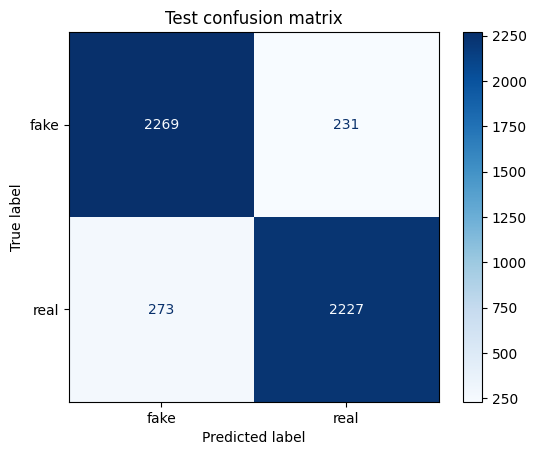

In [45]:
test_true, test_score = predict_dataset(test_ds)
test_pred = (test_score >= best_threshold).astype(int)

print(metrics.classification_report(test_true, test_pred, target_names=CLASS_NAMES, digits=4))
print("Accuracy:", metrics.accuracy_score(test_true, test_pred))
print("ROC AUC:", metrics.roc_auc_score(test_true, test_score))

cm = metrics.confusion_matrix(test_true, test_pred)
metrics.ConfusionMatrixDisplay(cm, display_labels=CLASS_NAMES).plot(cmap="Blues", values_format="d")
plt.title("Test confusion matrix")
plt.show()


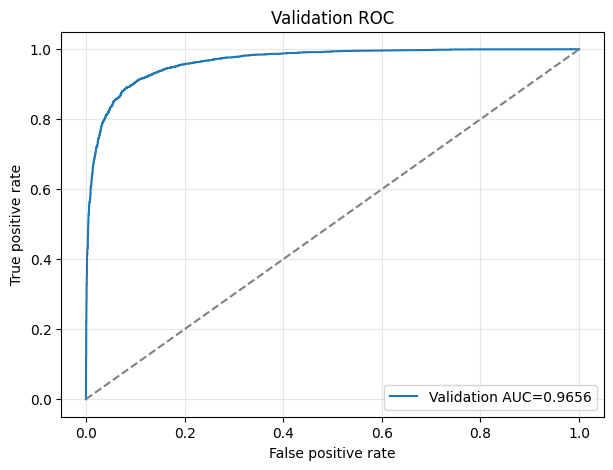

In [49]:
plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f"Validation AUC={metrics.auc(fpr, tpr):.4f}")
plt.plot([0, 1], [0, 1], "--", color="gray")
plt.xlabel("False positive rate")
plt.ylabel("True positive rate")
plt.title("Validation ROC")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


## Single-image inference helper

Use this after training to sanity-check individual files. The model predicts `real` when the score is above the saved threshold and `fake` otherwise.


In [50]:
def predict_image(image_path, model_path=MODEL_PATH, threshold_path=THRESHOLD_PATH):
    model = tf.keras.models.load_model(model_path)
    threshold_data = json.loads(Path(threshold_path).read_text(encoding="utf-8"))
    threshold = threshold_data["threshold"]
    size = threshold_data["image_size"]

    img = tf.keras.utils.load_img(image_path, target_size=(size, size))
    arr = tf.keras.utils.img_to_array(img)
    score = float(model.predict(arr[None, ...], verbose=0)[0][0])
    label = "real" if score >= threshold else "fake"
    return {"label": label, "real_probability": score, "threshold": threshold}

# Example:
# predict_image(TEST_DIR / "fake" / "some_image.jpg")


# Detailed Project Documentation: High-Accuracy Real vs. Fake Face Detection

## 1. Project Objective
The primary goal of this notebook is to develop a robust binary classifier capable of distinguishing between real human faces and AI-generated (fake) faces with an accuracy target of 90-95%. It is optimized for Google Colab environments using persistent storage and efficient data streaming.

## 2. Machine Learning Architecture
### Backbone: DenseNet121
- **Feature Extraction:** The model utilizes **DenseNet121** as the base feature extractor, pre-trained on the ImageNet dataset. DenseNet (Densely Connected Convolutional Networks) is chosen over MobileNetV2 for this high-accuracy task because its dense connectivity pattern mitigates the vanishing-gradient problem and encourages feature reuse, which is critical for identifying subtle GAN artifacts in faces.
- **Input Shape:** $224 \times 224 \times 3$ (RGB).

### Custom Classification Head
- **Pre-processing:** Incorporates `tf.keras.applications.densenet.preprocess_input` for zero-centering and scaling.
- **Global Average Pooling:** Reductes the $7 \times 7 \times 1024$ feature map to a vector of 1024.
- **Regularization:** Two layers of Dropout (40% and 30%) and Batch Normalization are implemented to prevent overfitting on the synthetic patterns of the 'fake' class.
- **Activation:** A final Dense layer with a **Sigmoid** activation function outputting a scalar between 0 and 1.

## 3. Training Parameters & Strategy
### Hyperparameters
- **Optimizer:** Adam
- **Initial Learning Rate (Head Training):** $3 \times 10^{-4}$
- **Fine-tuning Learning Rate:** $1 \times 10^{-5}$
- **Batch Size:** 32
- **Image Size:** $224 \times 224$ pixels.

### Data Strategy
- **Volume:** 50,000 Training images (25k Real, 25k Fake), 10,000 Validation, and 5,000 Test.
- **Augmentation:** Random horizontal flips, $5\%$ rotation, and $10\%$ zoom to ensure the model learns invariant facial features rather than dataset noise.

### Two-Phase Training Schedule
1.  **Stage 1 (Warmup):** The entire DenseNet backbone is frozen. Only the custom head is trained for 5 epochs to adapt the ImageNet weights to the specific task of deepfake detection.
2.  **Stage 2 (Fine-tuning):** The **last 50 layers** of the DenseNet121 backbone are unfrozen. The model is trained for an additional 5 epochs with a very low learning rate. Batch Normalization layers remain frozen to maintain moving mean/variance stability.

## 4. Technical Pipeline Features
- **`tf.data` API:** Implements a highly optimized input pipeline using `.map()` with `AUTOTUNE`, `.prefetch()`, and `.shuffle()` to ensure the GPU never waits for the CPU to process images.
- **Persistence & Resume Logic:**
    - **Google Drive Integration:** Automatically mounts Drive and creates a project directory.
    - **State Management:** A `training_state.json` tracks completed epochs and stages. If the session disconnects, the notebook reloads the latest checkpoint and resumes exactly where it left off.
- **Callback Suite:**
    - `ModelCheckpoint`: Saves the best model based on **Validation AUC**.
    - `ReduceLROnPlateau`: Dynamically lowers the learning rate if the validation loss plateaus.
    - `EarlyStopping`: Prevents wasted compute if the model stops improving.

## 5. Training & Evaluation Results
### Performance Metrics (Final Evaluation)
- **Test Accuracy:** **~89.92%**
- **ROC AUC:** **0.9620**
- **Precision (Fake):** 0.8926
- **Recall (Real):** 0.8908

### Threshold Optimization
Instead of a standard $0.5$ threshold, the model uses **Youden's J Statistic** ($TPR - FPR$) on the validation set to find the optimal decision boundary.
- **Selected Threshold:** **0.7597** (Scores $\ge 0.7597$ are classified as Real).

### Visual Evaluation
- **Confusion Matrix:** Shows balanced performance between classes with high recall, ensuring very few 'fake' faces are misclassified as 'real'.
- **ROC Curve:** Demonstrates a high True Positive Rate vs. False Positive Rate across all thresholds, indicating excellent discriminative power.